# Macrostate models

In [7]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd



from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm


from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### PCCA: populations, metastability, coherence

In [10]:
#-----------
tica_lag = 100 # lag time for TICA in frames, 1000 frames = 200 nanoseconds
tica_dim_distances = 5
tica_dim_dihedrals = 7
pca_dim_distances = 5
pca_dim_dihedrals = 7



tica_dihedrals = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_dihedrals}_dihedrals.npy")
pca_dihedrals = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_dihedrals}_dihedrals.npy")
tica_distances = np.load(f"../intermediate_outputs/dimred/tica_lag_{tica_lag}_dim_{tica_dim_distances}_distances.npy")
pca_distances = np.load(f"../intermediate_outputs/dimred/pca_dim_{pca_dim_distances}_distances.npy")
Q_timeseries = np.load(f"../intermediate_outputs/Q_timeseries_all.npy")
RMSD_timeseries = np.load(f"../intermediate_outputs/RMSD_crystal_nm.npy")

MOSAIC_Q_timeseries = [np.load(f"../intermediate_outputs/totdist_timeseries_MOSAIC{i}.npy") for i in range(1, 9)]



trajectories = [tica_distances, pca_distances, tica_dihedrals, pca_dihedrals]
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]
#------------

total_time_micros = 300
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames





macrostates_dict = {
    "tica_distances": 4,
    "pca_distances": 4,
    "tica_dihedrals": 4,
    "pca_dihedrals": 4
}


pcca_assignments_dict = {}

for i, name in enumerate(trajectories_labels):
    n_macro = macrostates_dict[name]
    assignments_timeseries = np.load(f"../intermediate_outputs/pcca/{n_macro}macro_{name}_assignments.npy")
    
    # Re-index the states
    median_Q_per_macrostate = []
    for id in range(n_macro):
        frames = Q_timeseries[assignments_timeseries == id]
        median_Q_per_macrostate.append(np.median(frames))
    
    # Renumber macrostates by median Q: S1=totally unfolded, Smax=totally folded
    sorted_indices = np.argsort(median_Q_per_macrostate)
    dict = {old: new for new, old in enumerate(sorted_indices)}

    pcca_assignments_dict[name] = np.array([dict[old] for old in assignments_timeseries])

Time step (microseconds) 0.00019658711659778472
Time step (nanoseconds) 0.19658711659778472
Time step (picoseconds) 196.58711659778473
One microsecond in frames 5086


---
#### Build markov model to estimate self-transition probabilities (metastability)

In [11]:
#msm_lag = 100 # same as for microstate msm
msm_lag = 100 * 5

estimator_counts = TransitionCountEstimator(lagtime=int(msm_lag), count_mode="sliding-effective")

estimator_transition = MaximumLikelihoodMSM(reversible=True, stationary_distribution_constraint=None)


macro_msm_dict = {}
for i, name in enumerate(trajectories_labels):
    n_macro = macrostates_dict[name]
    traj_pcca_assignments = pcca_assignments_dict[name]

    macro_counts = estimator_counts.fit(traj_pcca_assignments).fetch_model()
    macro_msm_dict[name] = estimator_transition.fit(macro_counts).fetch_model()

In [12]:
for name in trajectories_labels:
    print(f"{name}:")
    print("Transition matrix diagonal:")
    print(np.diag(macro_msm_dict[name].transition_matrix))
    print("Stationary distribution:")
    print(macro_msm_dict[name].stationary_distribution)
    print("Timescales (in frames):")
    print(macro_msm_dict[name].timescales(k=10))
    print("\n")

tica_distances:
Transition matrix diagonal:
[0.90658275 0.85018953 0.52543132 0.97518388]
Stationary distribution:
[0.26796173 0.00749595 0.04066049 0.68388183]
Timescales (in frames):
[6635.28138259 2947.30248611  692.97581758]


pca_distances:
Transition matrix diagonal:
[0.90249775 0.47515594 0.27113386 0.91152803]
Stationary distribution:
[0.27483834 0.0426826  0.06498299 0.61749607]
Timescales (in frames):
[6710.85690414  586.22521155  316.42425893]


tica_dihedrals:
Transition matrix diagonal:
[0.83983307 0.88606838 0.90964679 0.97416935]
Stationary distribution:
[0.03148745 0.00757382 0.26422283 0.69671589]
Timescales (in frames):
[6197.53496317 3966.6804911  2313.7528217 ]


pca_dihedrals:
Transition matrix diagonal:
[0.88827407 0.50749324 0.8124725  0.83848899]
Stationary distribution:
[0.26312829 0.03378417 0.38825598 0.31483156]
Timescales (in frames):
[4145.89785539 1309.21845693  676.95766832]




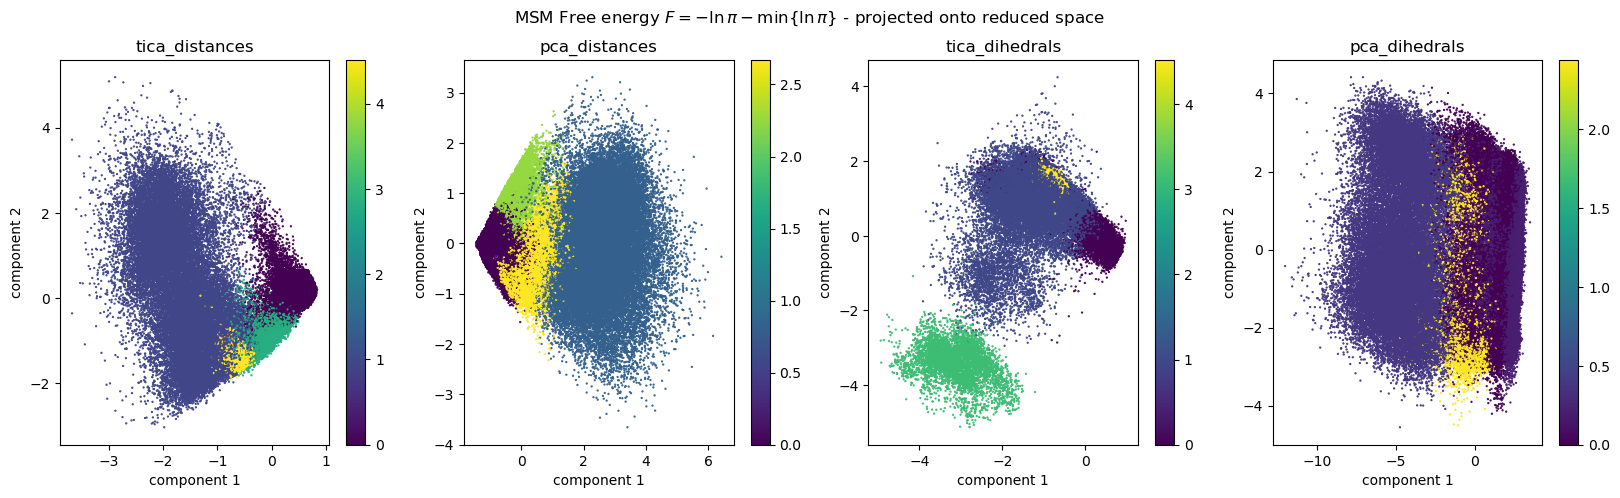

In [13]:
# plot stationary distribution of macrostates

plot_every_frames = 10

fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(20, 5))


for i, name in enumerate(trajectories_labels):

    traj = pcca_assignments_dict[name]
    pi = macro_msm_dict[name].stationary_distribution

    # transform  to free energy
    F = np.full_like(pi, np.nan)
    mask = pi > 0
    F[mask] = -np.log(pi[mask])
    F -= np.nanmin(F)

    z_values = np.full(len(traj), np.nan)
    mask = traj != -1
    z_values[mask] = F[traj[mask]]



    ax = axs[i]
    ax.scatter(trajectories[i][:, 0][::plot_every_frames], trajectories[i][:, 1][::plot_every_frames], c = z_values[::plot_every_frames], cmap = "viridis", s=0.4, alpha=1)
    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    ax.set_title(f"{name}")

plt.suptitle(r"MSM Free energy $F = -\ln{\pi} - \min\{{\ln{\pi}}\}$ - projected onto reduced space")   
plt.show()






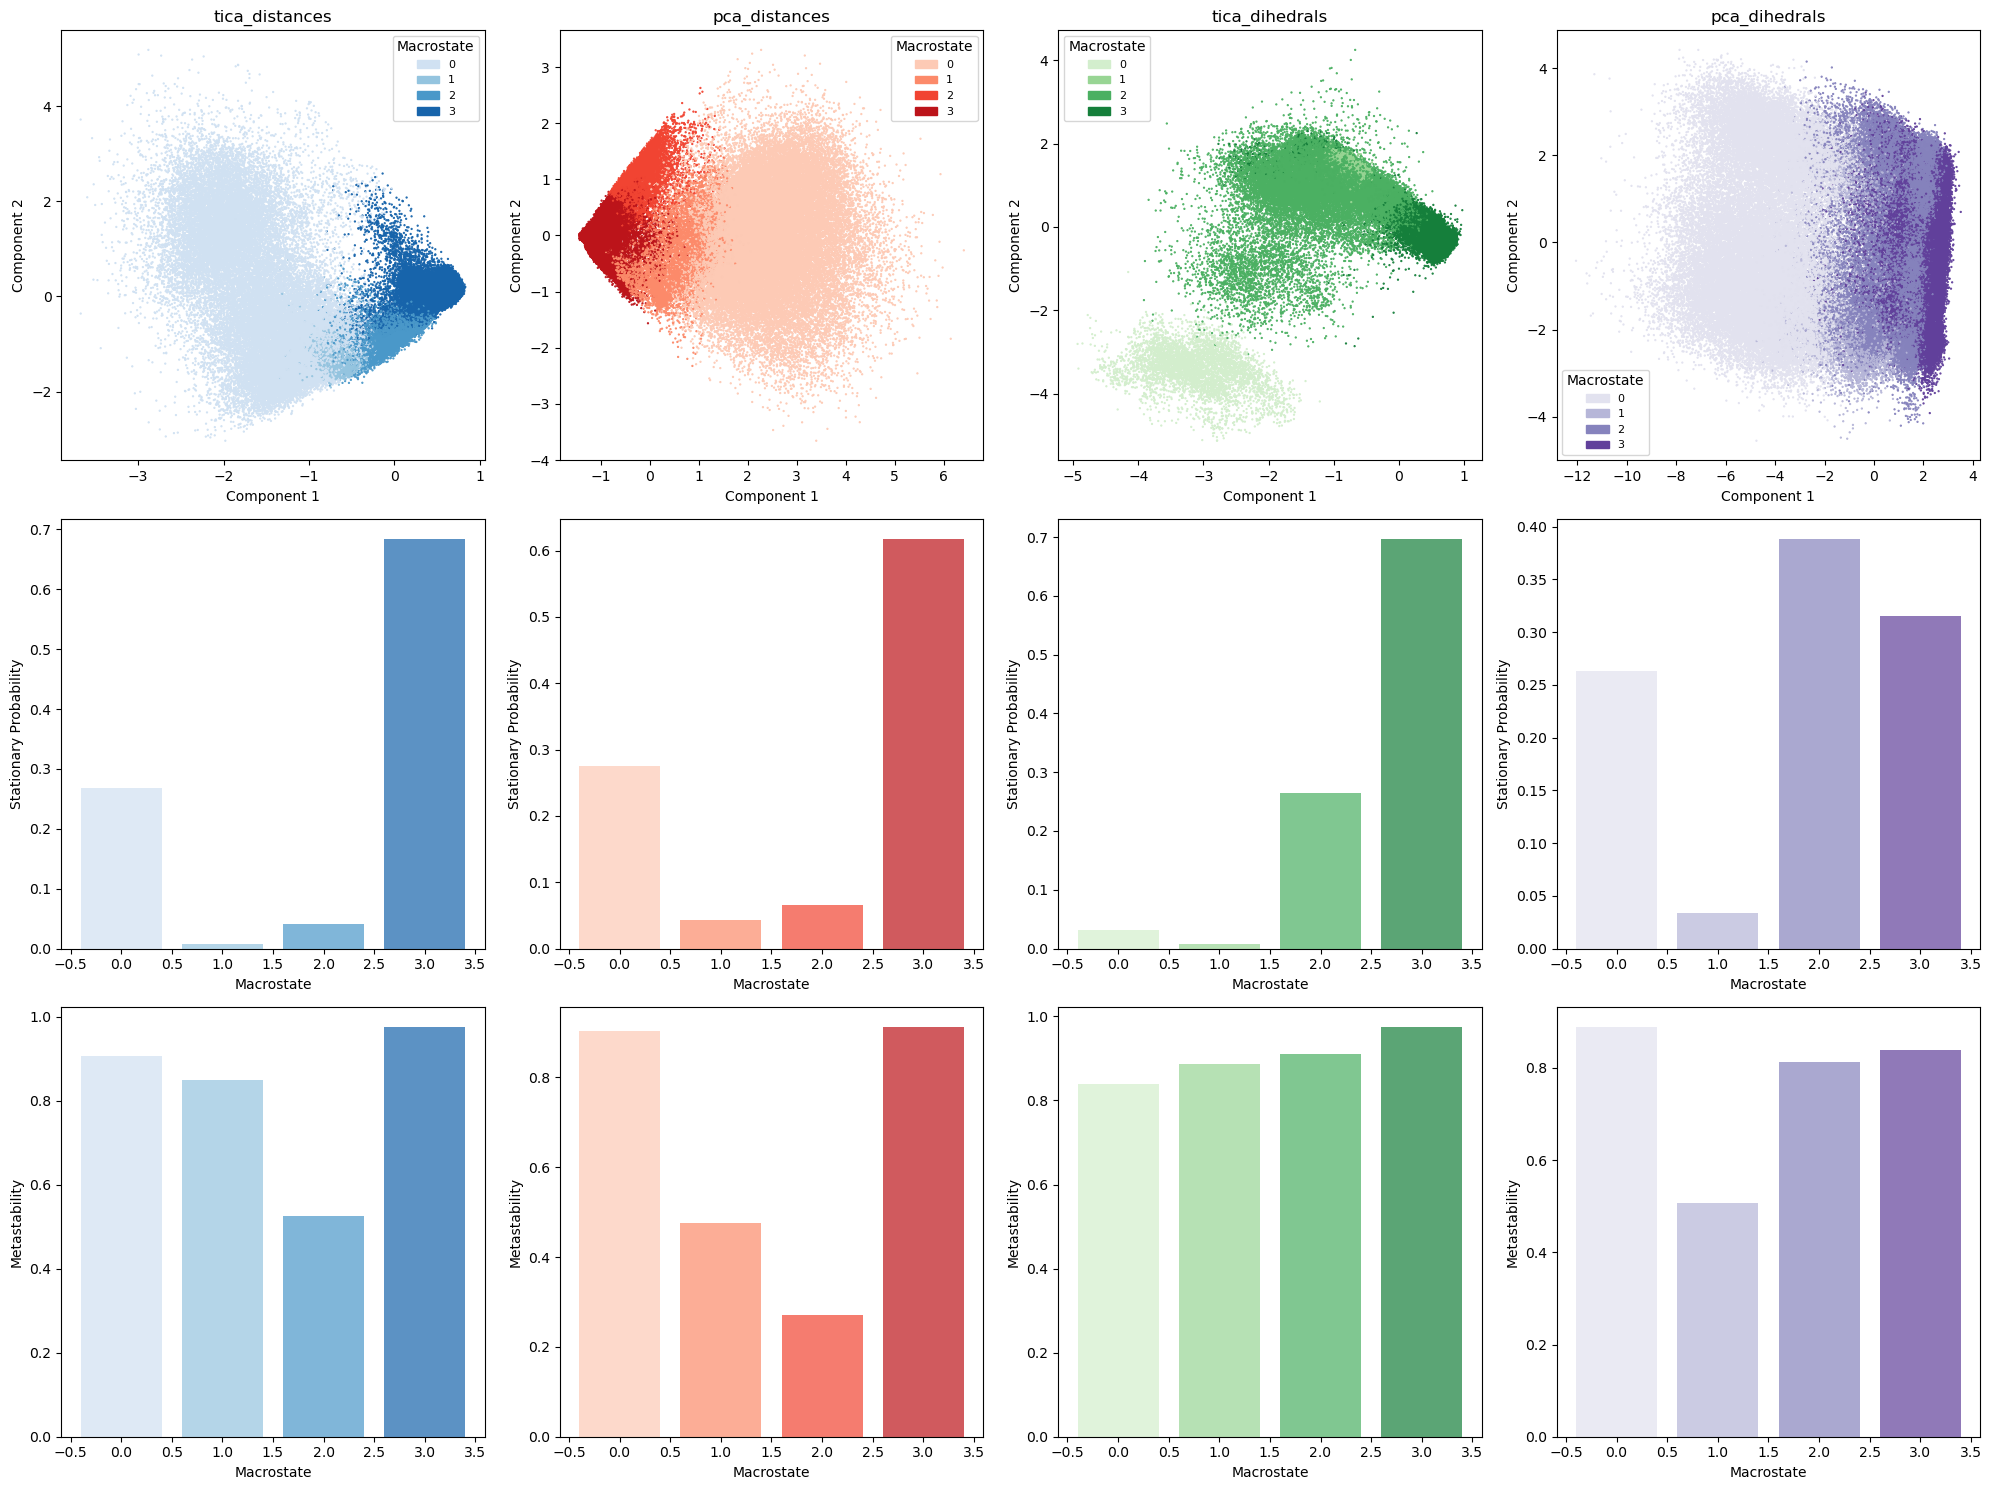

In [14]:
palette_names = ["Blues", "Reds", "Greens", "Purples"]

palettes = [sns.color_palette(palette_names[i], n_colors=macrostates_dict[name]) for i,name in enumerate(trajectories_labels)]


plot_every_frames = 10

fig, axs = plt.subplots(3, 4, figsize=(20, 15))

for i, name in enumerate(trajectories_labels):
    assignments = np.asarray(pcca_assignments_dict[name])
    states = np.unique(assignments[assignments != -1])

    # map states -> colors for this model only
    state_to_color = {state: palettes[i][j % len(palettes[i])] for j, state in enumerate(states)}

    colors = [
        state_to_color[s] if s != -1 else (0.8, 0.8, 0.8)
        for s in assignments[::plot_every_frames]
    ]

    ax = axs[0, i]

    ax.scatter(trajectories[i][:, 0][::plot_every_frames], trajectories[i][:, 1][::plot_every_frames], c=colors, s=0.4, alpha=1, rasterized=True)

    ax.set_title(name)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

    # legend for this panel
    handles = [Patch(color=state_to_color[s], label=f"{s}") for s in states]
    ax.legend(handles=handles, title="Macrostate", fontsize=8, loc="best")



    ax = axs[1, i]
    # Plot populations  of macrostates
    ax.bar(states, macro_msm_dict[name].stationary_distribution[states], color=[state_to_color[s] for s in states], alpha=0.7)
    ax.set_xlabel("Macrostate")
    ax.set_ylabel("Stationary Probability")



    ax = axs[2, i]
    # Plot metastability of macrostates
    ax.bar(states, np.diag(macro_msm_dict[name].transition_matrix), color=[state_to_color[s] for s in states], alpha=0.7)
    ax.set_xlabel("Macrostate")
    ax.set_ylabel("Metastability")




plt.tight_layout()
plt.show()

### correspondence between the description: Sankey diagrams

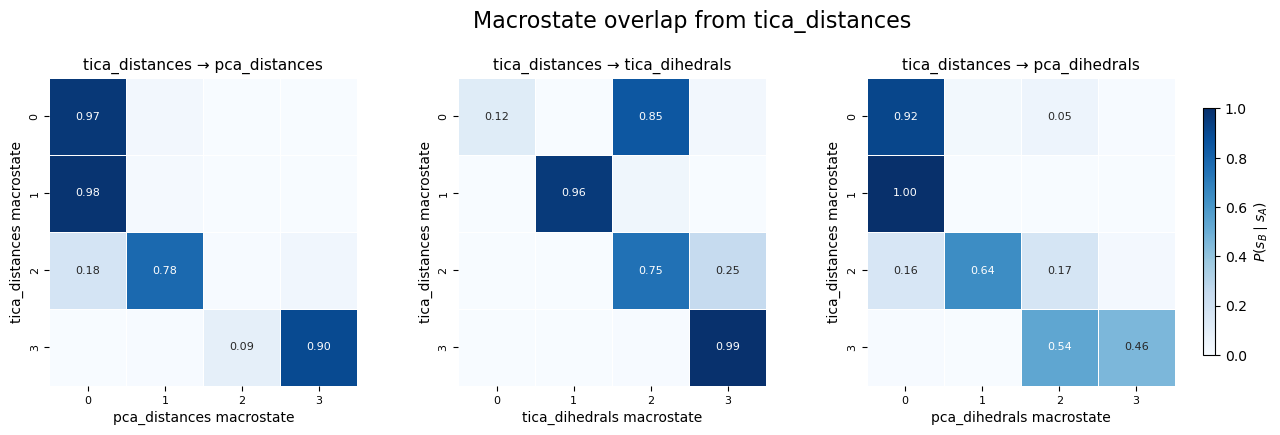

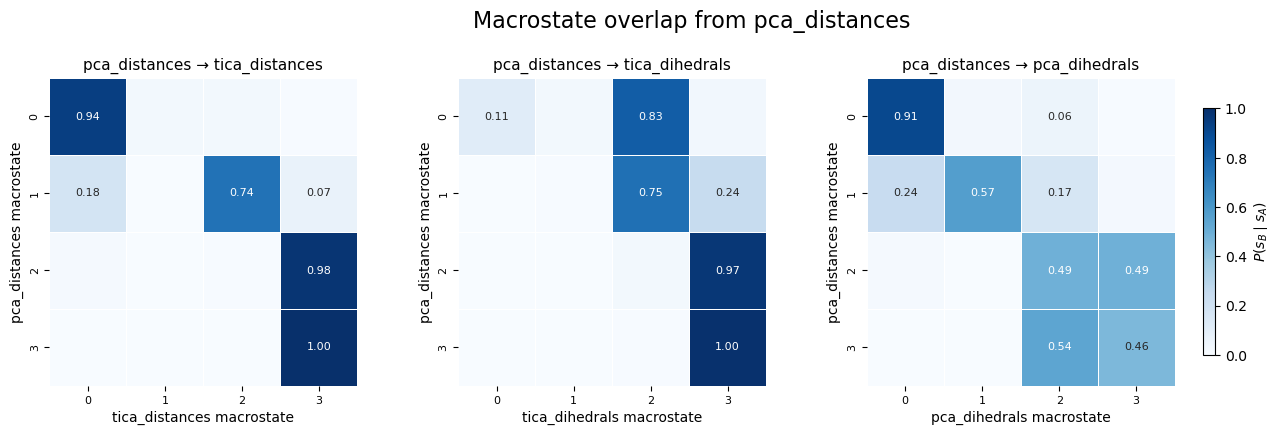

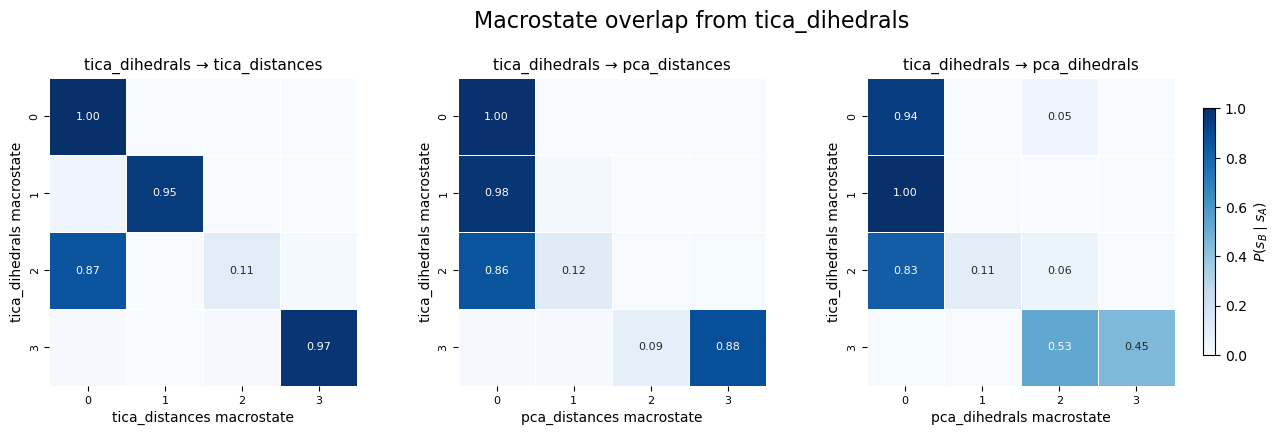

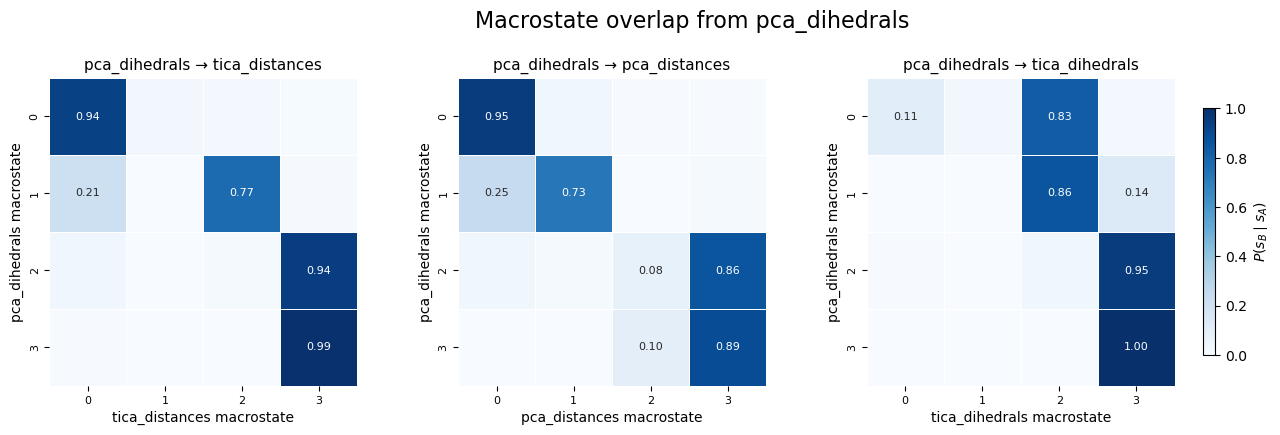

In [15]:
models = pcca_assignments_dict
model_names = trajectories_labels

for name_A in model_names:

    fig, axs = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
    axs = axs.flatten()

    k = 0
    for name_B in model_names:
        if name_A == name_B:
            continue

        ax = axs[k]
        k += 1

        A = np.asarray(models[name_A])
        B = np.asarray(models[name_B])

        mask = (A != -1) & (B != -1)

        table = pd.crosstab(A[mask], B[mask], normalize="index")

        # hide very small annotations
        annot = table.copy().astype(str)
        annot[:] = ""
        annot[table >= 0.05] = table[table >= 0.05].map(lambda x: f"{x:.2f}")

        sns.heatmap(
            table,
            ax=ax,
            cmap="Blues",
            vmin=0,
            vmax=1,
            annot=annot,
            fmt="",
            square=True,
            cbar=False,
            linewidths=0.5,
            linecolor="white",
            annot_kws={"fontsize": 8}
        )

        ax.set_title(f"{name_A} → {name_B}", fontsize=11)
        ax.set_xlabel(f"{name_B} macrostate")
        ax.set_ylabel(f"{name_A} macrostate")
        ax.tick_params(axis="both", labelsize=8)

    mappable = axs[0].collections[0]
    fig.colorbar(
        mappable,
        ax=axs,
        shrink=0.8,
        pad=0.02,
        label=r"$P(s_B \mid s_A)$"
    )

    fig.suptitle(f"Macrostate overlap from {name_A}", y=1.05, fontsize = 16)
    plt.show()
    print("\n\n\n\n")

    # Shared colorbar
    mappable = axs[0].collections[0]
    fig.colorbar(mappable, ax=axs, shrink=0.8, label=r"$P(s_B \mid s_A)$")
    plt.show()

---
# Structural caracterization: Q and RMSD

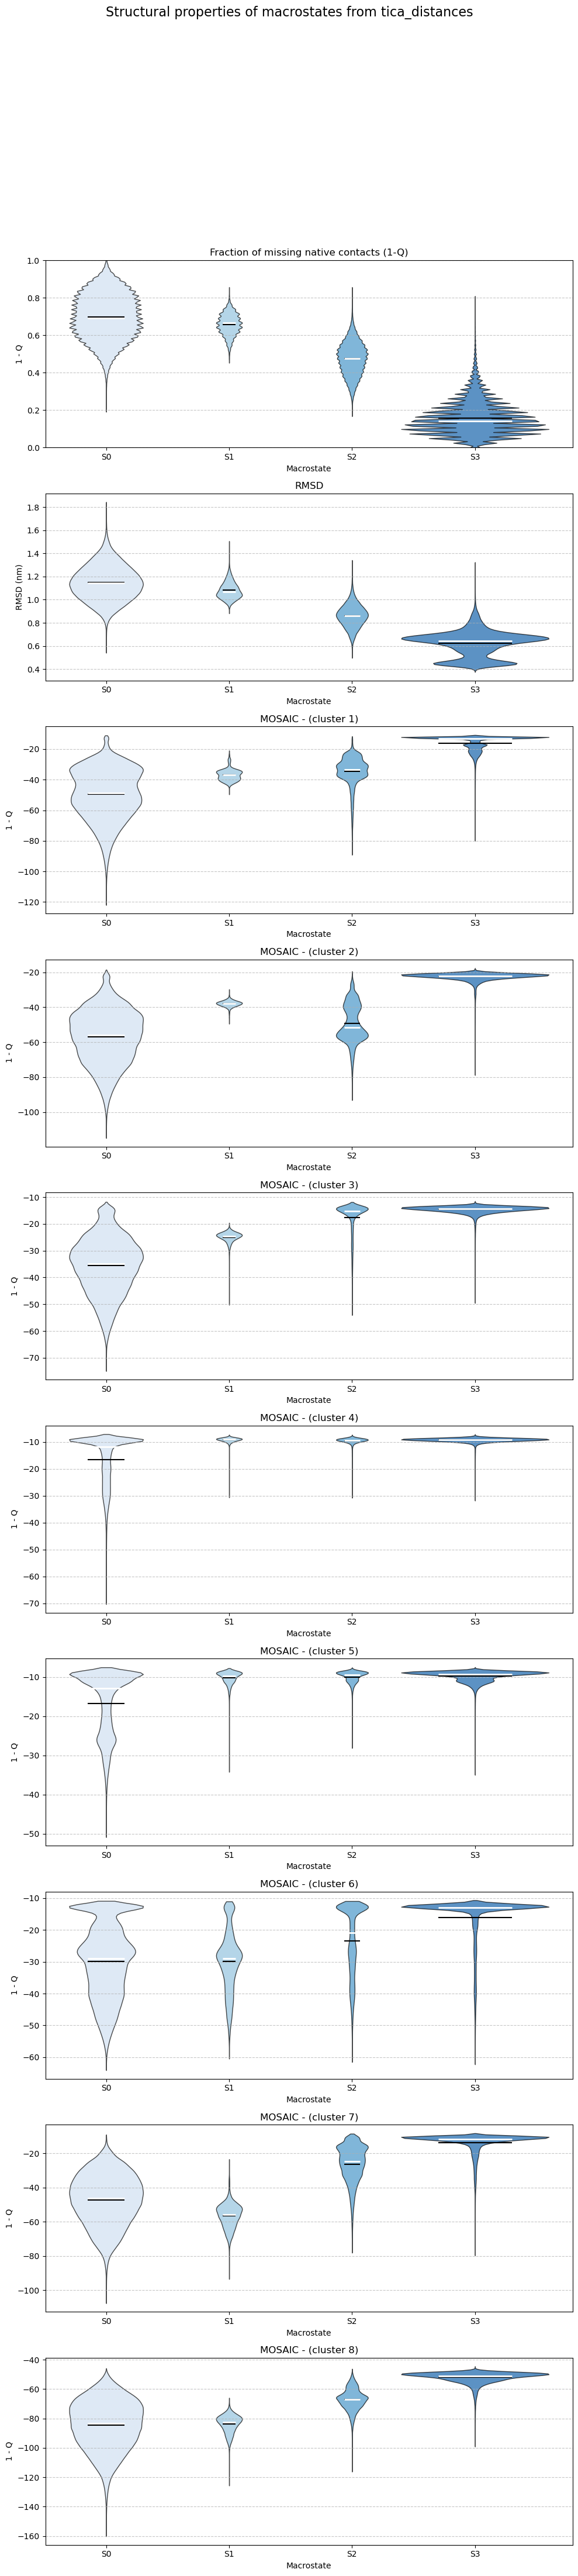

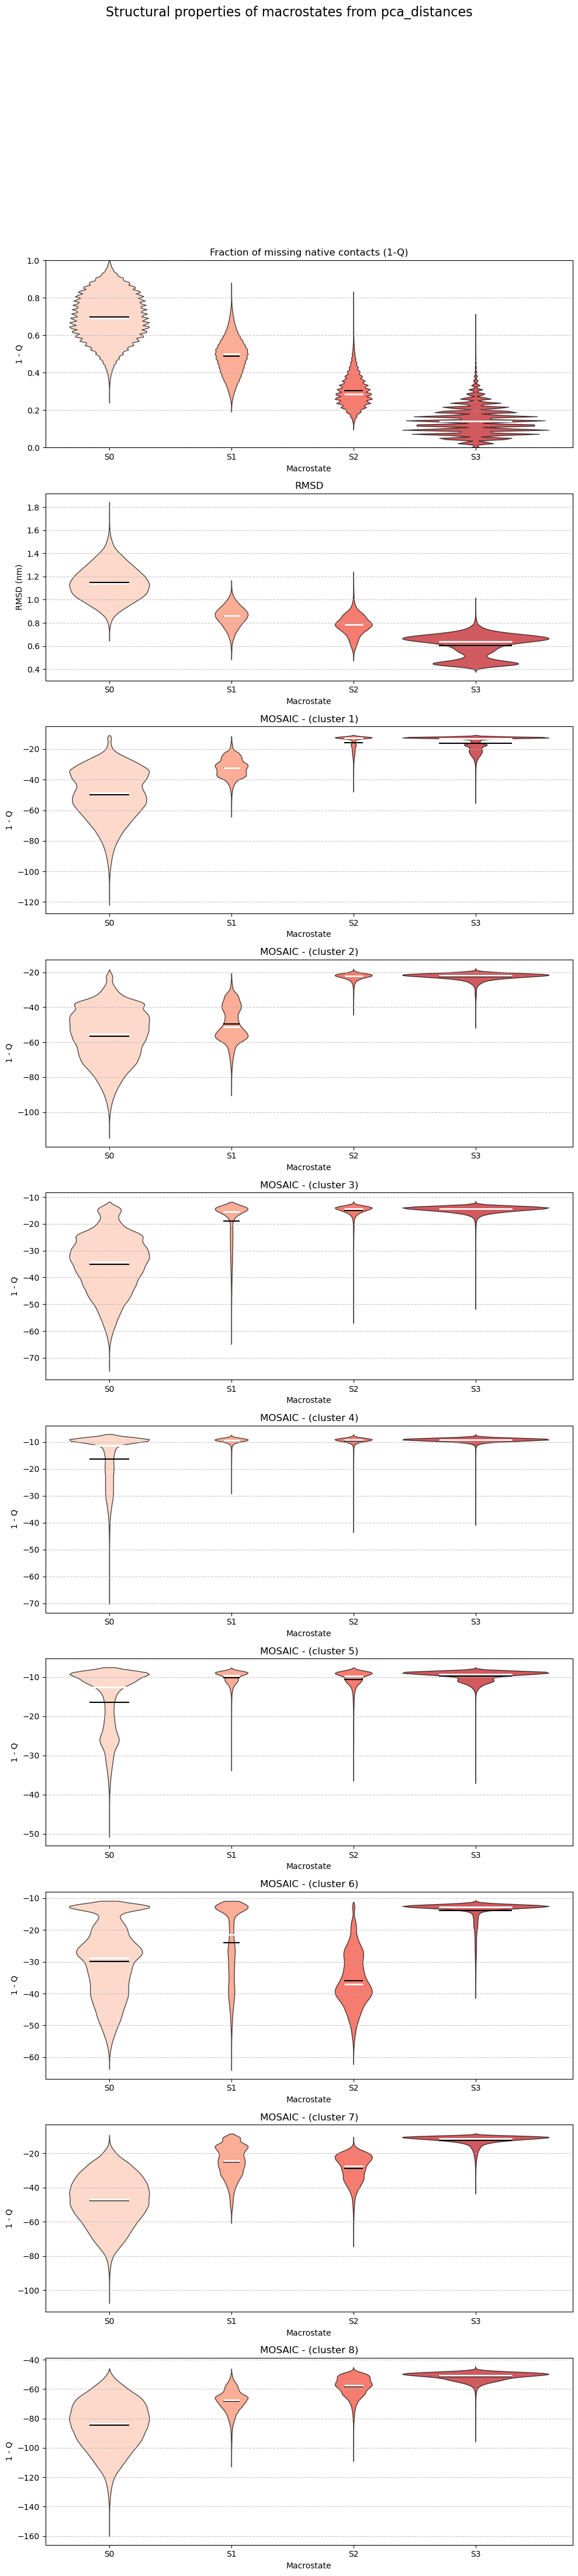

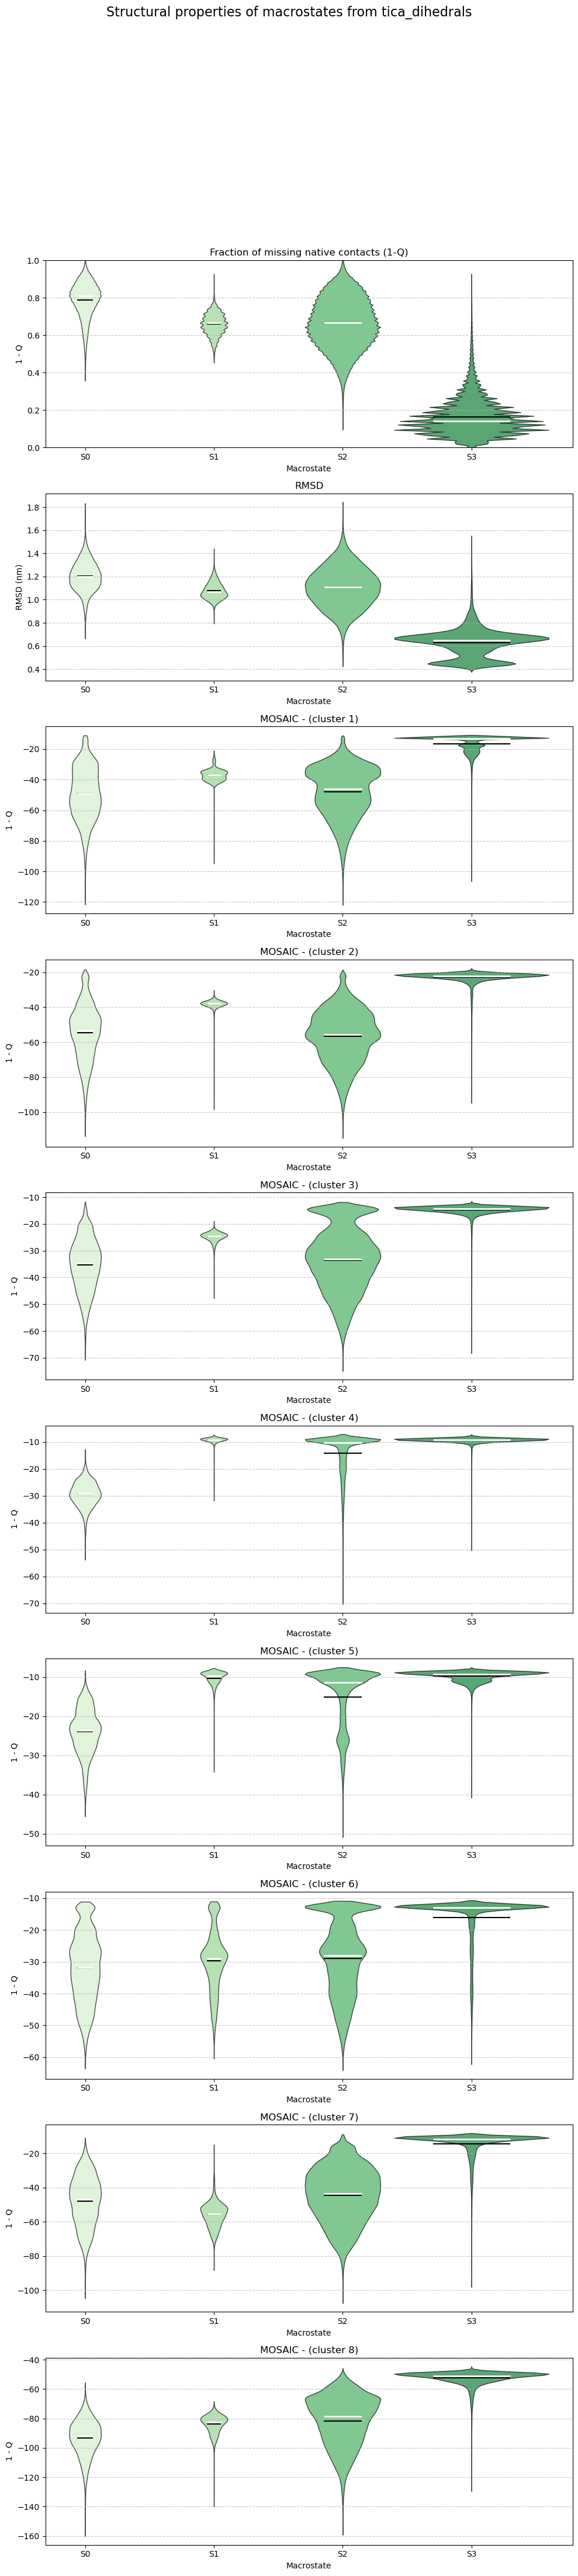

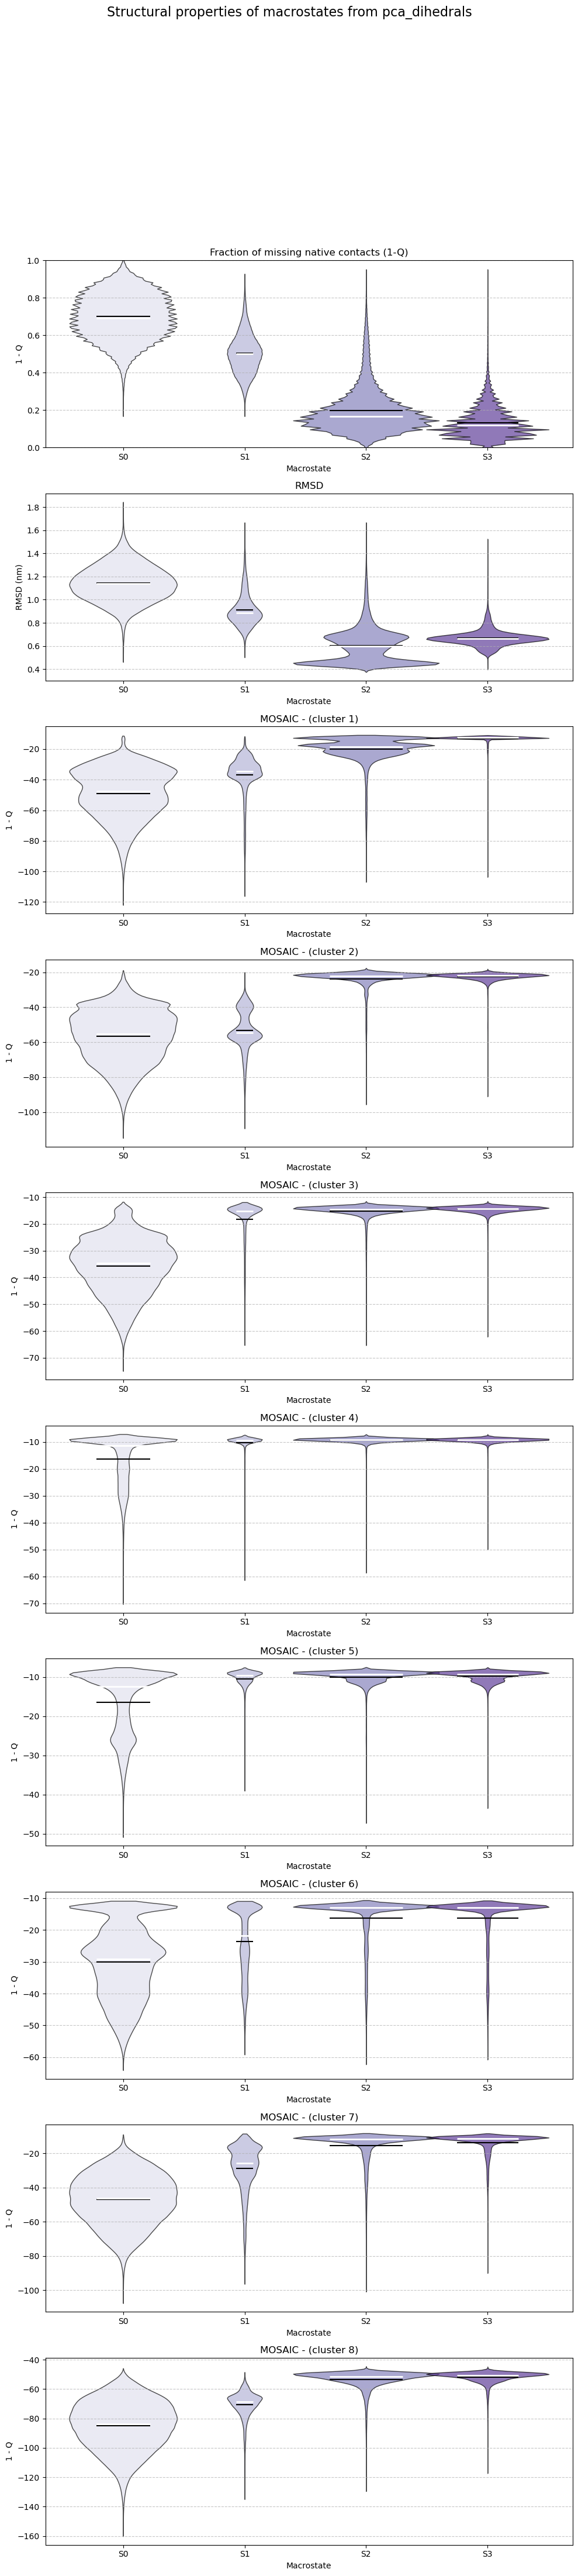

In [16]:
for i, name in enumerate(trajectories_labels):
    macro_traj = pcca_assignments_dict[name]
    n_macro = macrostates_dict[name]


    fig, axs = plt.subplots(nrows = 10, ncols = 1, figsize=(10, 40))


    ax = axs[0]
    ax, vp = pu.make_violin_plot(ax, macro_traj, 1- Q_timeseries, n_macro, macro_color_sequence = palettes[i])
    ax.set_title("Fraction of missing native contacts (1-Q)")
    ax.set_ylim(0, 1)
    ax.set_ylabel("1 - Q")
    ax.grid(axis='y', linestyle='--', alpha=0.7)


    ax = axs[1]
    ax, vp = pu.make_violin_plot(ax, macro_traj, RMSD_timeseries, n_macro, macro_color_sequence = palettes[i])
    ax.set_title("RMSD")
    ax.set_ylabel("RMSD (nm)")
    ax.grid(axis='y', linestyle='--', alpha=0.7)


    for mosaic in range(0, 8):
        ax = axs[mosaic + 2]
        ax, vp = pu.make_violin_plot(ax, macro_traj, 1 - MOSAIC_Q_timeseries[mosaic], n_macro, macro_color_sequence = palettes[i])
        ax.set_title(f"MOSAIC - (cluster {mosaic + 1})")
        ax.set_ylabel("1 - Q")
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.suptitle(f"Structural properties of macrostates from {name}", y=1.1, fontsize = 16)
    print("\n\n\n\n")
    plt.show()